In [1]:
from langgraph.graph import StateGraph,START,END

In [10]:
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [15]:
class GState(TypedDict):
    topic: str
    title: str
    blog : str
    outline : str


In [16]:
graph = StateGraph(GState)

In [17]:
llm = ChatGroq(model="openai/gpt-oss-120b") 

In [18]:
def generate(state: GState) -> str:
    """
    Generate a 3‑4‑word blog title from the user‑provided topic.
    Returns the raw title string (no surrounding quotes, no newline).
    """
    topic = state["topic"]

    # Using a single‑line f‑string keeps the prompt tidy.
    prompt = (
        f"From the topic the user provided, \"{topic}\", generate a short blog title:\n"
        "- 3‑4 words maximum\n"
        "- Simple, clear, and easy to understand\n"
        "- Title‑case (capitalize each major word)\n"
        "Answer only with the title, nothing else."
    )

    # You can tune temperature/stop tokens if you want deterministic titles.
    result = llm.invoke(prompt, temperature=0.2, stop=["\n"])
    title = result.content.strip()
    state["title"] = title
    return title

In [19]:
def blog(state: GState) -> str:
    """
    Given a populated `state` (must contain `title` and optionally `topic`),
    generate a full blog post.

    Returns the blog content as a plain‑text string and also writes it
    back into `state["content"]`.
    """
    # ------------------------------------------------------------------
    # 0️⃣  Guard‑rails – make sure we have what we need
    # ------------------------------------------------------------------
    if "title" not in state:
        # If the title is missing we fall back to `generate`.
        generate(state)

    title = state["title"]
    topic = state.get("topic", "")

    # ------------------------------------------------------------------
    # 1️⃣  Create a short outline (helps the model stay structured)
    # ------------------------------------------------------------------
    outline_prompt = (
        f"Write a concise 4‑point outline for a blog post titled \"{title}\".\n"
        "Each point should be a short phrase that could become a section heading.\n"
        "Return the outline as a numbered list (1., 2., 3., 4.)."
    )
    outline_result = llm.invoke(outline_prompt, temperature=0.3)
    outline = outline_result.content.strip()

    # Store the outline for debugging / future reuse
    state["outline"] = outline

    # ------------------------------------------------------------------
    # 2️⃣  Expand the outline into a full article
    # ------------------------------------------------------------------
    # You can tweak the desired length with a token‑budget or word‑count.
    # Here we ask for ~800‑1000 words (≈ 5‑6 paragraphs per section).
    article_prompt = (
        f"Using the outline below, write a complete blog post.\n"
        f"Title: {title}\n"
        f"Outline:\n{outline}\n\n"
        "Guidelines:\n"
        "- Write in a friendly, conversational tone.\n"
        "- Keep sentences short and easy to read.\n"
        "- Include a brief introduction (2‑3 sentences) that hooks the reader.\n"
        "- For each outline point, write 2‑3 paragraphs (≈ 120‑150 words each).\n"
        "- End with a short conclusion (2‑3 sentences) that summarizes the key take‑aways.\n"
        "- Do NOT include the outline itself in the final output.\n"
        "- Use markdown headings: `#` for the title, `##` for each section.\n"
        "- Keep total length around 800‑1000 words.\n"
        "Write the article now."
    )
    article_result = llm.invoke(article_prompt, temperature=0.6)
    article = article_result.content.strip()

    # ------------------------------------------------------------------
    # 3️⃣  Persist & return
    # ------------------------------------------------------------------
    state["content"] = article
    return article

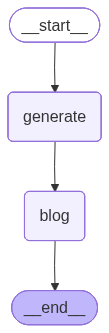

In [20]:
graph.add_node("generate",generate)
graph.add_node("blog",blog)

graph.add_edge(START,"generate")
graph.add_edge("generate","blog")
graph.add_edge("blog",END)

app = graph.compile()

app

In [21]:
# Example usage ---------------------------------------------------------
state = {
    "topic": "sustainable home gardening for beginners"
}

# 1️⃣ Generate the title (adds `title` to the state)
title = generate(state)
print("✅ Title:", title)

✅ Title: Sustainable Home Gardening Basics


In [22]:
# 2️⃣ Generate the full blog post (adds `outline` and `content` to the state)
article = blog(state)
print("\n--- BLOG POST START ---\n")
print(article)
print("\n--- BLOG POST END ---\n")


--- BLOG POST START ---

# Sustainable Home Gardening Basics

Ever dreamed of a garden that looks great *and* does good for the planet? Let’s explore simple steps that make your backyard greener, cheaper, and easier to care for.

## Choosing Native and Drought‑Resistant Plants  

Native plants are the unsung heroes of a low‑maintenance garden. They have evolved right here, so they know how to thrive in our soil, climate, and local pests. When you plant a native wildflower or shrub, you’re giving pollinators a familiar food source and reducing the need for extra water or fertilizer. Look for species that bloom at different times; this keeps the garden colorful all season while supporting insects that rely on continuous nectar.

Drought‑resistant varieties take the water‑saving idea a step further. Succulents, lavender, and many ornamental grasses store moisture in their leaves or stems. They can survive long dry spells with only occasional watering. Pairing these tough plants with a fe